In [1]:
import numpy as np
import datetime
import matplotlib.pyplot as plt
import pickle
import pyproj
from pyproj import Proj, transform
import rasterio
from rasterio.plot import show
import matplotlib.colors as colors
from scipy.signal import find_peaks

In [2]:
roots = "C:\\Users\\simcosta\\Documents\\doc\\Campo_2023\\Campo_2023\\Processados\\"
file_names = ['dados_gps.pkl', 'dados_ctd.pkl']

# Dicionário para armazenar os dados já processados de velocidadee outros
data = {}

# Loop através dos nomes dos arquivos e carrega os dados usando pickle
for file_name in file_names:
    with open(roots+file_name, 'rb') as file:
        data[file_name.replace('.pkl', '')] = pickle.load(file)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0466925].


(np.float64(-52.15),
 np.float64(-52.08),
 np.float64(-32.21),
 np.float64(-32.15))

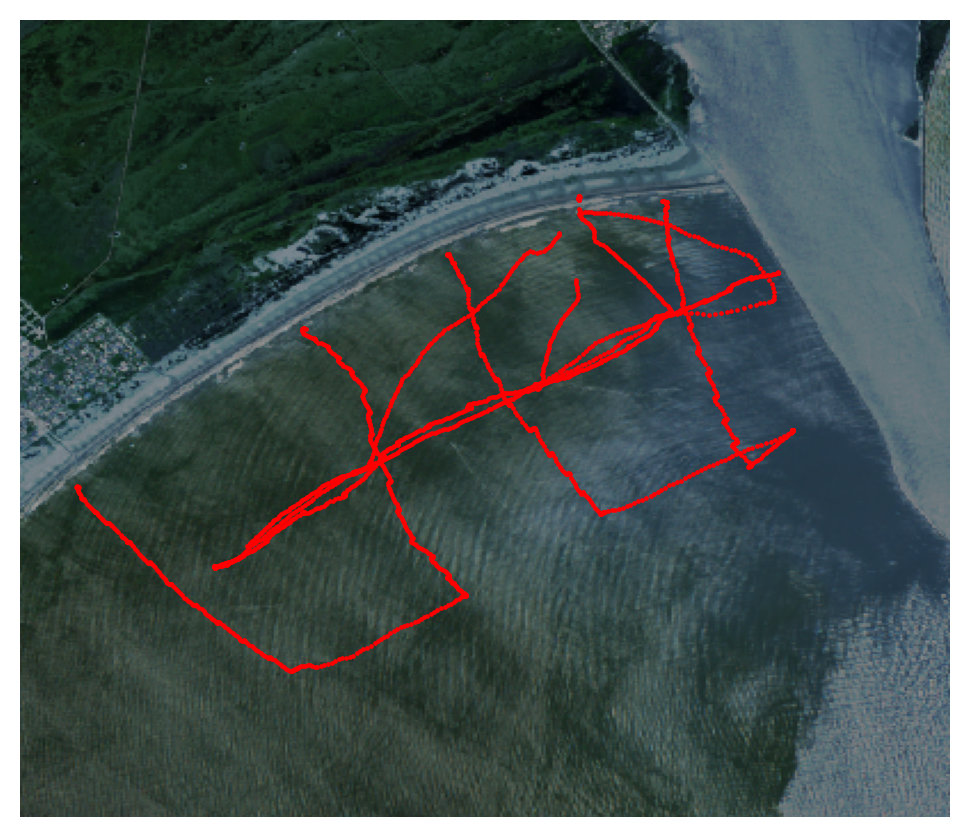

In [3]:
fp ='C:\\Users\\simcosta\\Documents\\doc\\Campo_2023\\Campo_2023\\dados_brutos\\2023-11-23-00_00_2023-11-23-23_59_Sentinel-2_L2A_Highlight_Optimized_Natural_Color.tiff'
img = rasterio.open(fp)
red_band = img.read(3) 
green_band = img.read(2)
blue_band = img.read(1)

# Reorganiza as bandas para RGB
rgb_img = np.stack([red_band, green_band, blue_band], axis=-1)

fig, ax = plt.subplots(figsize=(6, 6), dpi=200)

# Exibir a imagem rasterio
ax.imshow(rgb_img, extent=[img.bounds.left, img.bounds.right, img.bounds.bottom, img.bounds.top])
ax.scatter(data['dados_gps'][:][1], data['dados_gps'][:][2], s=0.5, color ='r')
ax.set_xlim([-52.15, -52.08])
ax.set_ylim([-32.21, -32.15])
ax.axis('off')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0466925].


(np.float64(-52.15),
 np.float64(-52.08),
 np.float64(-32.21),
 np.float64(-32.15))

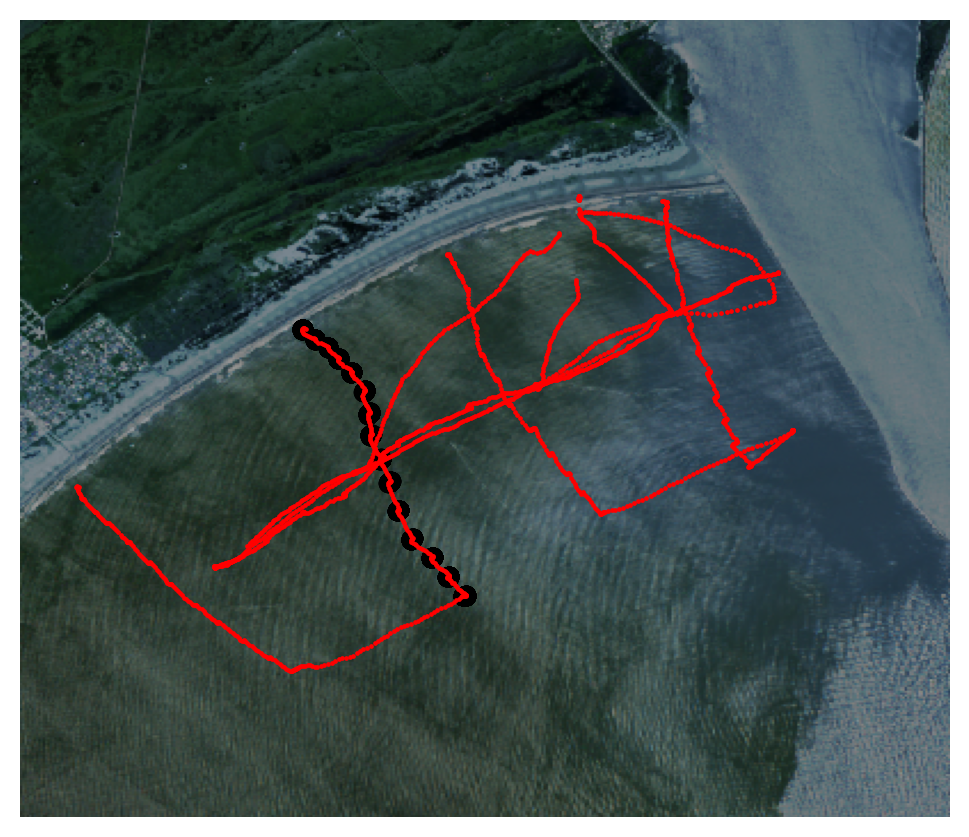

In [4]:
myProj = Proj('+proj=utm +zone=22 +south +datum=WGS84 +units=m +no_defs')

lon0 = np.interp(data['dados_ctd'][20][0][:], data['dados_gps'][0][:], data['dados_gps'][1][:])
lat0 = np.interp(data['dados_ctd'][20][0][:], data['dados_gps'][0][:], data['dados_gps'][2][:])

fig, ax = plt.subplots(figsize=(6, 6), dpi=200)

# Exibir a imagem rasterio
ax.imshow(rgb_img, extent=[img.bounds.left, img.bounds.right, img.bounds.bottom, img.bounds.top])
ax.scatter(lon0, lat0, color = 'k')
ax.scatter(data['dados_gps'][:][1], data['dados_gps'][:][2], s=0.5, color ='r')
ax.set_xlim([-52.15, -52.08])
ax.set_ylim([-32.21, -32.15])
ax.axis('off')

In [5]:
sua_serie_de_dados = np.array(data['dados_ctd'][20][1][:])

# Define um valor limite
limite = 0.9

# Encontre os picos na série de dados
derivada = np.diff(sua_serie_de_dados)
mudanca_sinal = derivada[:-1] * derivada[1:]
pontos_de_mudanca = np.where((mudanca_sinal < 0) & (sua_serie_de_dados[:-2] < limite))[0] + 1
pontos_de_mudanca

array([ 153,  238,  335,  444,  593,  804,  823, 1091, 1094, 1096, 1294,
       1295, 1296, 1304, 1315, 1489, 1492, 1497, 1501, 1725, 1743, 1938,
       1939, 1941, 1943, 1946, 2140, 2141, 2145, 2147, 2157, 2376, 2377,
       2382, 2623, 2626, 2628, 2629, 2630, 2631, 2634, 2907, 2909, 2910,
       2913, 2919])

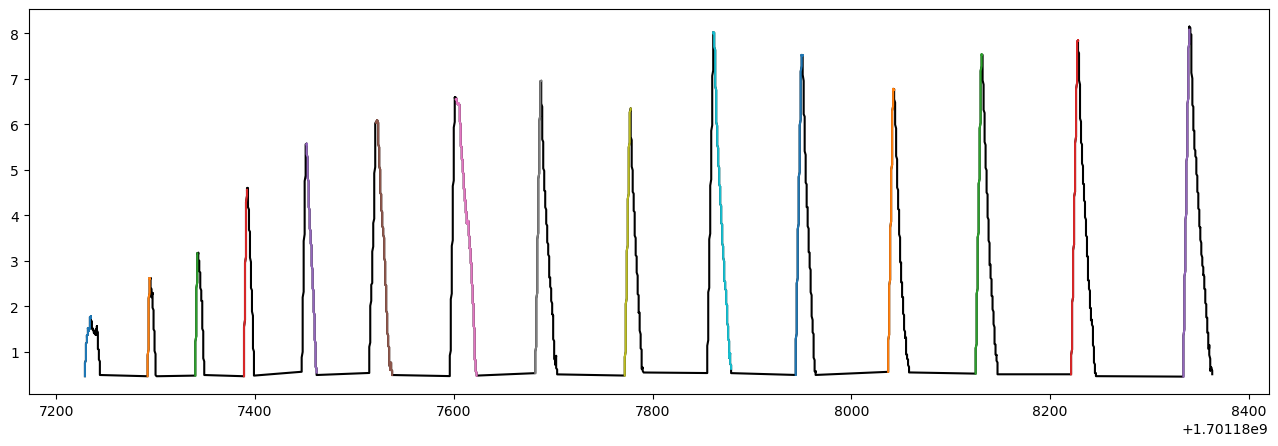

In [6]:
fig, ax = plt.subplots(figsize=(16, 5), dpi=100)

ax.plot(data['dados_ctd'][20][0][:], data['dados_ctd'][20][1][:], 'k')
ax.plot(data['dados_ctd'][20][0][0:62], data['dados_ctd'][20][1][0:62])
ax.plot(data['dados_ctd'][20][0][153:178], data['dados_ctd'][20][1][153:178])
ax.plot(data['dados_ctd'][20][0][239:265], data['dados_ctd'][20][1][239:265])
ax.plot(data['dados_ctd'][20][0][335:369], data['dados_ctd'][20][1][335:369])
ax.plot(data['dados_ctd'][20][0][489:593], data['dados_ctd'][20][1][489:593])
ax.plot(data['dados_ctd'][20][0][660:823], data['dados_ctd'][20][1][660:823])
ax.plot(data['dados_ctd'][20][0][887:1096], data['dados_ctd'][20][1][887:1096])
ax.plot(data['dados_ctd'][20][0][1097:1154], data['dados_ctd'][20][1][1097:1154])
ax.plot(data['dados_ctd'][20][0][1315:1372], data['dados_ctd'][20][1][1315:1372])
ax.plot(data['dados_ctd'][20][0][1566:1742], data['dados_ctd'][20][1][1566:1742])
ax.plot(data['dados_ctd'][20][0][1743:1814], data['dados_ctd'][20][1][1743:1814])
ax.plot(data['dados_ctd'][20][0][1947:2007], data['dados_ctd'][20][1][1947:2007])
ax.plot(data['dados_ctd'][20][0][2157:2220], data['dados_ctd'][20][1][2157:2220])
ax.plot(data['dados_ctd'][20][0][2383:2453], data['dados_ctd'][20][1][2383:2453])
ax.plot(data['dados_ctd'][20][0][2634:2696], data['dados_ctd'][20][1][2634:2696])







#ax.plot(data['dados_ctd'][20][0][], data['dados_ctd'][20][1][])



In [7]:
z_norm = np.arange(0.3,8.55,0.05)
sal_norm = np.zeros((15,165))
turb_norm = np.zeros((15,165))
cla_norm = np.zeros((15,165))
od_norm = np.zeros((15,165))
temp_norm = np.zeros((15,165))
dens_norm = np.zeros((15,165))

time_norm = []
time_norm.append(np.mean(data['dados_ctd'][20][0][0:62]))
time_norm.append(np.mean(data['dados_ctd'][20][0][153:178]))
time_norm.append(np.mean(data['dados_ctd'][20][0][239:265]))
time_norm.append(np.mean(data['dados_ctd'][20][0][335:369]))
time_norm.append(np.mean(data['dados_ctd'][20][0][489:593]))
time_norm.append(np.mean(data['dados_ctd'][20][0][660:823]))
time_norm.append(np.mean(data['dados_ctd'][20][0][887:1096]))
time_norm.append(np.mean(data['dados_ctd'][20][0][1097:1154]))
time_norm.append(np.mean(data['dados_ctd'][20][0][1315:1372]))
time_norm.append(np.mean(data['dados_ctd'][20][0][1566:1742]))
time_norm.append(np.mean(data['dados_ctd'][20][0][1743:1814]))
time_norm.append(np.mean(data['dados_ctd'][20][0][1947:2007]))
time_norm.append(np.mean(data['dados_ctd'][20][0][2157:2220]))
time_norm.append(np.mean(data['dados_ctd'][20][0][2383:2453]))
time_norm.append(np.mean(data['dados_ctd'][20][0][2634:2696]))





2023-11-28 13:08:04.842105


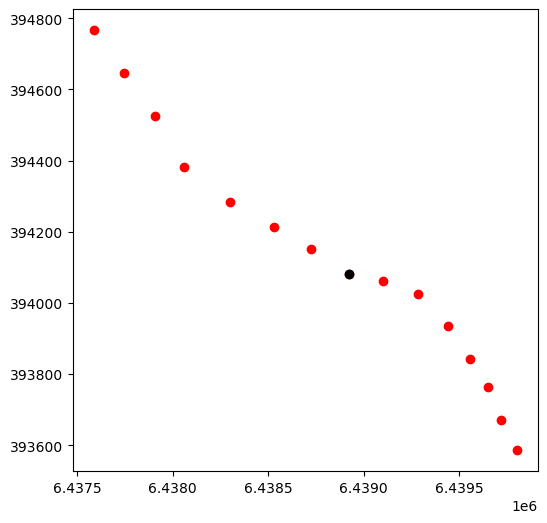

In [8]:
myProj = Proj('+proj=utm +zone=22 +south +datum=WGS84 +units=m +no_defs')
ctd_loc =  np.zeros((15, 2))

fig, ax = plt.subplots(figsize=(6, 6), dpi=100)

for i in range(0,15):
    lon0 = np.interp(time_norm[i], data['dados_gps'][0][:], data['dados_gps'][1][:])
    lat0 = np.interp(time_norm[i], data['dados_gps'][0][:], data['dados_gps'][2][:])
    ctd_loc[i,0],ctd_loc[i,1] = myProj(lon0, lat0) 
    ax.scatter(ctd_loc[i,1], ctd_loc[i,0], color = 'r')


ctd_dist = np.sqrt((ctd_loc[1:,0] - ctd_loc[:-1,0])**2 + (ctd_loc[1:,1] - ctd_loc[:-1,1])**2)
ctd_cumdist = np.cumsum(ctd_dist)
ctd_cumdist = np.insert(ctd_cumdist, 0, 0)


P1_utm_E_init = 396102.197559
P1_utm_N_init = 6439967.08943

P2_utm_E_init = 395259.915163
P2_utm_N_init = 6439348.88736

P3_utm_E_init = 393947.507994
P3_utm_N_init = 6438615.82996

P4_utm_E_init = 393106.974459
P4_utm_N_init = 6437854.43456


ax.scatter(ctd_loc[7,1], ctd_loc[7,0], color = 'k')
print(datetime.datetime.fromtimestamp(time_norm[7]))

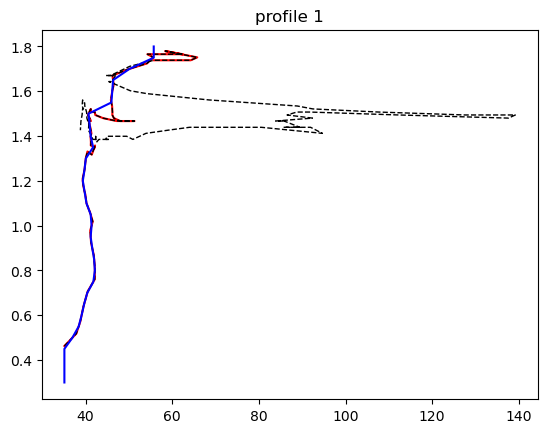

In [9]:
# 0:127
trash1 = np.interp(z_norm, data['dados_ctd'][20][1][0:62], data['dados_ctd'][20][3][0:62])
trash2 = np.interp(z_norm, data['dados_ctd'][20][1][0:62], data['dados_ctd'][20][5][0:62])
trash3 = np.interp(z_norm, data['dados_ctd'][20][1][0:62], data['dados_ctd'][20][4][0:62])
trash4 = np.interp(z_norm, data['dados_ctd'][20][1][0:62], data['dados_ctd'][20][6][0:62])
trash5 = np.interp(z_norm, data['dados_ctd'][20][1][0:62], data['dados_ctd'][20][2][0:62])
trash6 = np.interp(z_norm, data['dados_ctd'][20][1][0:62], data['dados_ctd'][20][7][0:62])
trash1[31:] = np.nan
trash2[31:] = np.nan
trash3[31:] = np.nan
trash4[31:] = np.nan
trash5[31:] = np.nan
trash6[31:] = np.nan

plt.title('profile 1')
plt.plot(data['dados_ctd'][20][5][0:62], data['dados_ctd'][20][1][0:62], 'r')
plt.plot(data['dados_ctd'][20][5][0:127], data['dados_ctd'][20][1][0:127], 'k', ls='--', lw=1)
plt.plot(trash2, z_norm, 'b')




sal_norm[0] = trash1
turb_norm[0] = trash2
cla_norm[0] = trash3
od_norm[0] = trash4
temp_norm[0] = trash5
dens_norm[0] = trash6

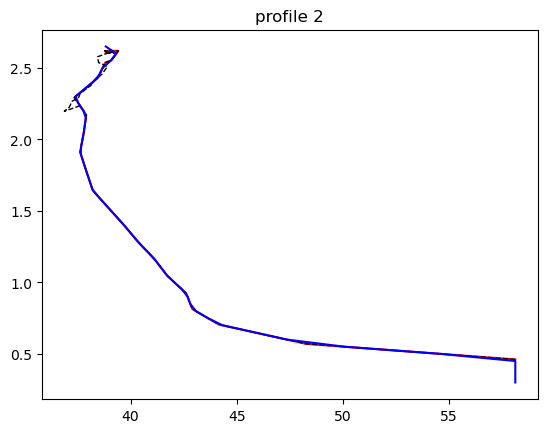

In [10]:
trash1 = np.interp(z_norm, data['dados_ctd'][20][1][153:178], data['dados_ctd'][20][3][153:178])
trash2 = np.interp(z_norm, data['dados_ctd'][20][1][153:178], data['dados_ctd'][20][5][153:178])
trash3 = np.interp(z_norm, data['dados_ctd'][20][1][153:178], data['dados_ctd'][20][4][153:178])
trash4 = np.interp(z_norm, data['dados_ctd'][20][1][153:178], data['dados_ctd'][20][6][153:178])
trash5 = np.interp(z_norm, data['dados_ctd'][20][1][153:178], data['dados_ctd'][20][2][153:178])
trash6 = np.interp(z_norm, data['dados_ctd'][20][1][153:178], data['dados_ctd'][20][7][153:178])
trash1[48:] = np.nan
trash2[48:] = np.nan
trash3[48:] = np.nan
trash4[48:] = np.nan
trash5[48:] = np.nan
trash6[48:] = np.nan

plt.title('profile 2')
plt.plot(data['dados_ctd'][20][5][153:178], data['dados_ctd'][20][1][153:178], 'r')
plt.plot(data['dados_ctd'][20][5][153:198], data['dados_ctd'][20][1][153:198], 'k', ls='--', lw=1)
plt.plot(trash2, z_norm, 'b')



sal_norm[1] = trash1
turb_norm[1] = trash2
cla_norm[1] = trash3
od_norm[1] = trash4
temp_norm[1] = trash5
dens_norm[1] = trash6

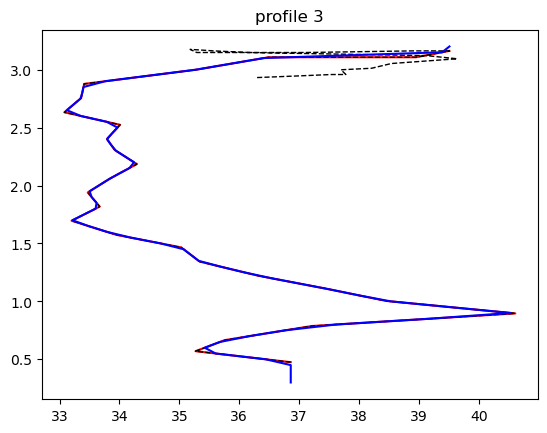

In [11]:
trash1 = np.interp(z_norm, data['dados_ctd'][20][1][239:265], data['dados_ctd'][20][3][239:265])
trash2 = np.interp(z_norm, data['dados_ctd'][20][1][239:265], data['dados_ctd'][20][5][239:265])
trash3 = np.interp(z_norm, data['dados_ctd'][20][1][239:265], data['dados_ctd'][20][4][239:265])
trash4 = np.interp(z_norm, data['dados_ctd'][20][1][239:265], data['dados_ctd'][20][6][239:265])
trash5 = np.interp(z_norm, data['dados_ctd'][20][1][239:265], data['dados_ctd'][20][2][239:265])
trash6 = np.interp(z_norm, data['dados_ctd'][20][1][239:265], data['dados_ctd'][20][7][239:265])
trash1[59:] = np.nan
trash2[59:] = np.nan
trash3[59:] = np.nan
trash4[59:] = np.nan
trash5[59:] = np.nan
trash6[59:] = np.nan

plt.title('profile 3')
plt.plot(data['dados_ctd'][20][5][239:265], data['dados_ctd'][20][1][239:265], 'r')
plt.plot(data['dados_ctd'][20][5][239:282], data['dados_ctd'][20][1][239:282], 'k', ls='--', lw=1)
plt.plot(trash2, z_norm, 'b')



sal_norm[2] = trash1
turb_norm[2] = trash2
cla_norm[2] = trash3
od_norm[2] = trash4
temp_norm[2] = trash5
dens_norm[2] = trash6

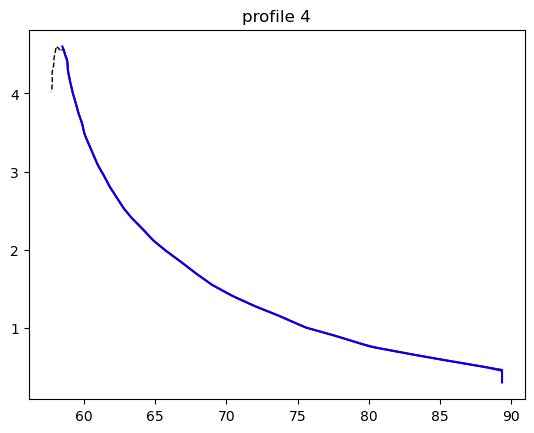

In [12]:
trash1 = np.interp(z_norm, data['dados_ctd'][20][1][335:369], data['dados_ctd'][20][3][335:369])
trash2 = np.interp(z_norm, data['dados_ctd'][20][1][335:369], data['dados_ctd'][20][5][335:369])
trash3 = np.interp(z_norm, data['dados_ctd'][20][1][335:369], data['dados_ctd'][20][4][335:369])
trash4 = np.interp(z_norm, data['dados_ctd'][20][1][335:369], data['dados_ctd'][20][6][335:369])
trash5 = np.interp(z_norm, data['dados_ctd'][20][1][335:369], data['dados_ctd'][20][2][335:369])
trash6 = np.interp(z_norm, data['dados_ctd'][20][1][335:369], data['dados_ctd'][20][7][335:369])
trash1[87:] = np.nan
trash2[87:] = np.nan
trash3[87:] = np.nan
trash4[87:] = np.nan
trash5[87:] = np.nan
trash6[87:] = np.nan

plt.title('profile 4')
plt.plot(data['dados_ctd'][20][6][335:369], data['dados_ctd'][20][1][335:369], 'r')
plt.plot(data['dados_ctd'][20][6][335:389], data['dados_ctd'][20][1][335:389], 'k', ls='--', lw=1)
plt.plot(trash4, z_norm, 'b')



sal_norm[3] = trash1
turb_norm[3] = trash2
cla_norm[3] = trash3
od_norm[3] = trash4
temp_norm[3] = trash5
dens_norm[3] = trash6

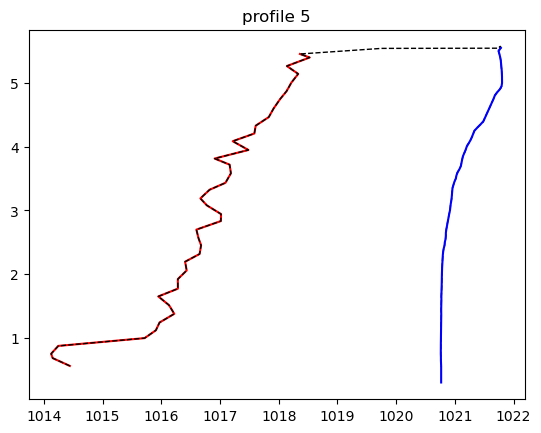

In [13]:
trash1 = np.interp(z_norm, np.flip(data['dados_ctd'][20][1][486:593]), np.flip(data['dados_ctd'][20][3][486:593]))
trash2 = np.interp(z_norm, (data['dados_ctd'][20][1][445:485]), (data['dados_ctd'][20][5][445:485]))
trash3 = np.interp(z_norm, (data['dados_ctd'][20][1][445:485]), (data['dados_ctd'][20][4][445:485]))
trash4 = np.interp(z_norm, (data['dados_ctd'][20][1][445:485]), (data['dados_ctd'][20][6][445:485]))
trash5 = np.interp(z_norm, (data['dados_ctd'][20][1][445:485]), (data['dados_ctd'][20][2][445:485]))
trash6 = np.interp(z_norm, np.flip(data['dados_ctd'][20][1][486:593]), np.flip(data['dados_ctd'][20][7][486:593]))
trash1[106:] = np.nan
trash2[106:] = np.nan
trash3[106:] = np.nan
trash4[106:] = np.nan
trash5[106:] = np.nan
trash6[106:] = np.nan

plt.title('profile 5')
plt.plot(data['dados_ctd'][20][7][445:485], data['dados_ctd'][20][1][445:485], 'r')
plt.plot(data['dados_ctd'][20][7][445:593], data['dados_ctd'][20][1][445:593], 'k', ls='--', lw=1)
plt.plot(trash6, z_norm, 'b')



sal_norm[4] = trash1
turb_norm[4] = trash2
cla_norm[4] = trash3
od_norm[4] = trash4
temp_norm[4] = trash5
dens_norm[4] = trash6

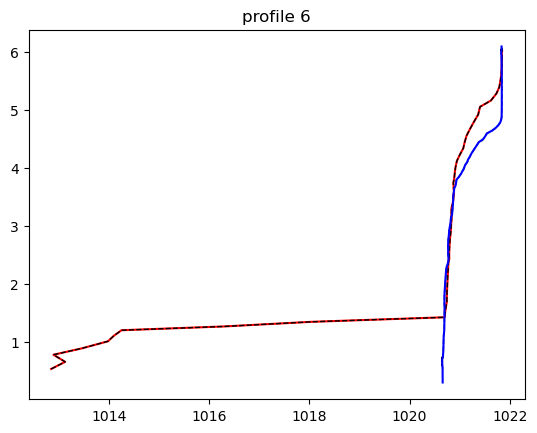

In [14]:
trash1 = np.interp(z_norm, np.flip(data['dados_ctd'][20][1][661:823]), np.flip(data['dados_ctd'][20][3][661:823]))
trash2 = np.interp(z_norm, (data['dados_ctd'][20][1][594:660]), (data['dados_ctd'][20][5][594:660]))
trash3 = np.interp(z_norm, (data['dados_ctd'][20][1][594:660]), (data['dados_ctd'][20][4][594:660]))
trash4 = np.interp(z_norm, (data['dados_ctd'][20][1][594:660]), (data['dados_ctd'][20][6][594:660]))
trash5 = np.interp(z_norm, (data['dados_ctd'][20][1][594:660]), (data['dados_ctd'][20][2][594:660]))
trash6 = np.interp(z_norm, np.flip(data['dados_ctd'][20][1][661:823]), np.flip(data['dados_ctd'][20][7][661:823]))
trash1[117:] = np.nan
trash2[117:] = np.nan
trash3[117:] = np.nan
trash4[117:] = np.nan
trash5[117:] = np.nan
trash6[117:] = np.nan

plt.title('profile 6')
plt.plot(data['dados_ctd'][20][7][594:660], data['dados_ctd'][20][1][594:660], 'r')
plt.plot(data['dados_ctd'][20][7][594:823], data['dados_ctd'][20][1][594:823], 'k', ls='--', lw=1)
plt.plot(trash6, z_norm, 'b')



sal_norm[5] = trash1
turb_norm[5] = trash2
cla_norm[5] = trash3
od_norm[5] = trash4
temp_norm[5] = trash5
dens_norm[5] = trash6

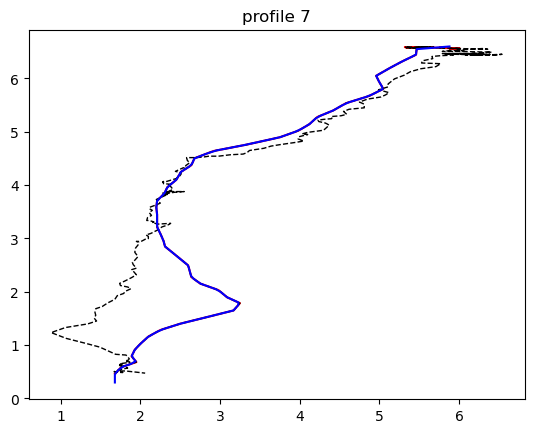

In [15]:
trash1 = np.interp(z_norm, np.flip(data['dados_ctd'][20][1][887:1096]), np.flip(data['dados_ctd'][20][3][887:1096]))
trash2 = np.interp(z_norm, np.flip(data['dados_ctd'][20][1][887:1096]), np.flip(data['dados_ctd'][20][5][887:1096]))
trash3 = np.interp(z_norm, (data['dados_ctd'][20][1][823:886]), (data['dados_ctd'][20][4][823:886]))
trash4 = np.interp(z_norm, (data['dados_ctd'][20][1][823:886]), (data['dados_ctd'][20][6][823:886]))
trash5 = np.interp(z_norm, np.flip(data['dados_ctd'][20][1][887:1096]), np.flip(data['dados_ctd'][20][2][887:1096]))
trash6 = np.interp(z_norm, np.flip(data['dados_ctd'][20][1][887:1096]), np.flip(data['dados_ctd'][20][7][887:1096]))
trash1[127:] = np.nan
trash2[127:] = np.nan
trash3[127:] = np.nan
trash4[127:] = np.nan
trash5[127:] = np.nan
trash6[127:] = np.nan

plt.title('profile 7')
plt.plot(data['dados_ctd'][20][4][823:887], data['dados_ctd'][20][1][823:887], 'r')
plt.plot(data['dados_ctd'][20][4][823:1096], data['dados_ctd'][20][1][823:1096], 'k', ls='--', lw=1)
plt.plot(trash3, z_norm, 'b')



sal_norm[6] = trash1
turb_norm[6] = trash2
cla_norm[6] = trash3
od_norm[6] = trash4
temp_norm[6] = trash5
dens_norm[6] = trash6

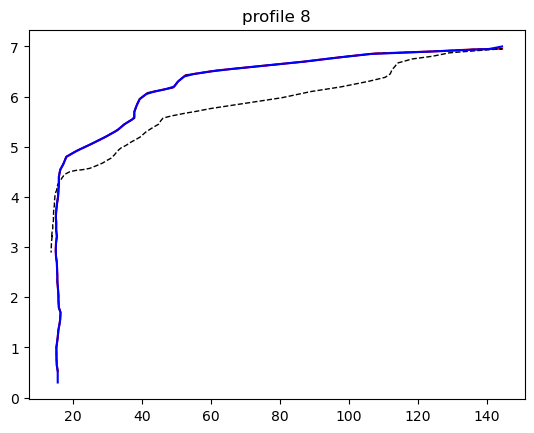

In [16]:
trash1 = np.interp(z_norm, data['dados_ctd'][20][1][1097:1154], data['dados_ctd'][20][3][1097:1154])
trash2 = np.interp(z_norm, data['dados_ctd'][20][1][1097:1154], data['dados_ctd'][20][5][1097:1154])
trash3 = np.interp(z_norm, data['dados_ctd'][20][1][1097:1154], data['dados_ctd'][20][4][1097:1154])
trash4 = np.interp(z_norm, data['dados_ctd'][20][1][1097:1154], data['dados_ctd'][20][6][1097:1154])
trash5 = np.interp(z_norm, data['dados_ctd'][20][1][1097:1154], data['dados_ctd'][20][2][1097:1154])
trash6 = np.interp(z_norm, data['dados_ctd'][20][1][1097:1154], data['dados_ctd'][20][7][1097:1154])
trash1[135:] = np.nan
trash2[135:] = np.nan
trash3[135:] = np.nan
trash4[135:] = np.nan
trash5[135:] = np.nan
trash6[135:] = np.nan

plt.title('profile 8')
plt.plot(data['dados_ctd'][20][5][1097:1154], data['dados_ctd'][20][1][1097:1154], 'r')
plt.plot(data['dados_ctd'][20][5][1097:1237], data['dados_ctd'][20][1][1097:1237], 'k', ls='--', lw=1)
plt.plot(trash2, z_norm, 'b')



sal_norm[7] = trash1
turb_norm[7] = trash2
cla_norm[7] = trash3
od_norm[7] = trash4
temp_norm[7] = trash5
dens_norm[7] = trash6

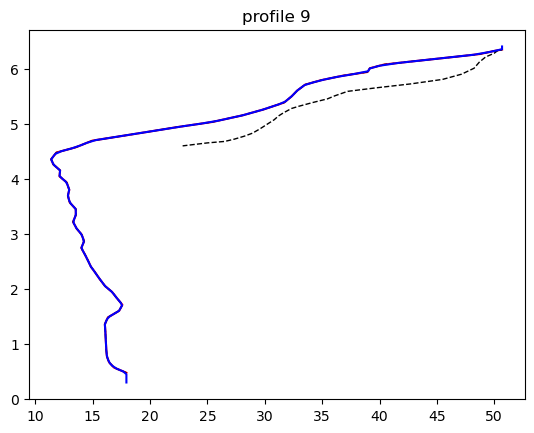

In [17]:
trash1 = np.interp(z_norm, data['dados_ctd'][20][1][1315:1372], data['dados_ctd'][20][3][1315:1372])
trash2 = np.interp(z_norm, data['dados_ctd'][20][1][1315:1372], data['dados_ctd'][20][5][1315:1372])
trash3 = np.interp(z_norm, data['dados_ctd'][20][1][1315:1372], data['dados_ctd'][20][4][1315:1372])
trash4 = np.interp(z_norm, data['dados_ctd'][20][1][1315:1372], data['dados_ctd'][20][6][1315:1372])
trash5 = np.interp(z_norm, data['dados_ctd'][20][1][1315:1372], data['dados_ctd'][20][2][1315:1372])
trash6 = np.interp(z_norm, data['dados_ctd'][20][1][1315:1372], data['dados_ctd'][20][7][1315:1372])
trash1[123:] = np.nan
trash2[123:] = np.nan
trash3[123:] = np.nan
trash4[123:] = np.nan
trash5[123:] = np.nan
trash6[123:] = np.nan

plt.title('profile 9')
plt.plot(data['dados_ctd'][20][5][1315:1372], data['dados_ctd'][20][1][1315:1372], 'r')
plt.plot(data['dados_ctd'][20][5][1315:1398], data['dados_ctd'][20][1][1315:1398], 'k', ls='--', lw=1)
plt.plot(trash2, z_norm, 'b')



sal_norm[8] = trash1
turb_norm[8] = trash2
cla_norm[8] = trash3
od_norm[8] = trash4
temp_norm[8] = trash5
dens_norm[8] = trash6

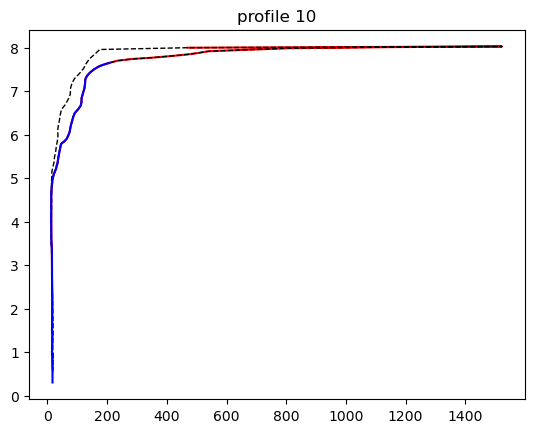

In [18]:
trash1 = np.interp(z_norm, np.flip(data['dados_ctd'][20][1][1566:1742]), np.flip(data['dados_ctd'][20][3][1566:1742]))
trash2 = np.interp(z_norm, np.flip(data['dados_ctd'][20][1][1566:1742]), np.flip(data['dados_ctd'][20][5][1566:1742]))
trash3 = np.interp(z_norm, (data['dados_ctd'][20][1][1501:1565]), (data['dados_ctd'][20][4][1501:1565]))
trash4 = np.interp(z_norm, (data['dados_ctd'][20][1][1501:1565]), (data['dados_ctd'][20][6][1501:1565]))
trash5 = np.interp(z_norm, np.flip(data['dados_ctd'][20][1][1566:1742]), np.flip(data['dados_ctd'][20][2][1566:1742]))
trash6 = np.interp(z_norm, np.flip(data['dados_ctd'][20][1][1566:1742]), np.flip(data['dados_ctd'][20][7][1566:1742]))
trash1[148:] = np.nan
trash2[148:] = np.nan
trash3[148:] = np.nan
trash4[148:] = np.nan
trash5[148:] = np.nan
trash6[148:] = np.nan

plt.title('profile 10')
plt.plot(data['dados_ctd'][20][5][1566:1742], data['dados_ctd'][20][1][1566:1742], 'r')
plt.plot(data['dados_ctd'][20][5][1501:1742], data['dados_ctd'][20][1][1501:1742], 'k', ls='--', lw=1)
plt.plot(trash2, z_norm, 'b')
#plt.xlim([0,300])


sal_norm[9] = trash1
turb_norm[9] = trash2
cla_norm[9] = trash3
od_norm[9] = trash4
temp_norm[9] = trash5
dens_norm[9] = trash6

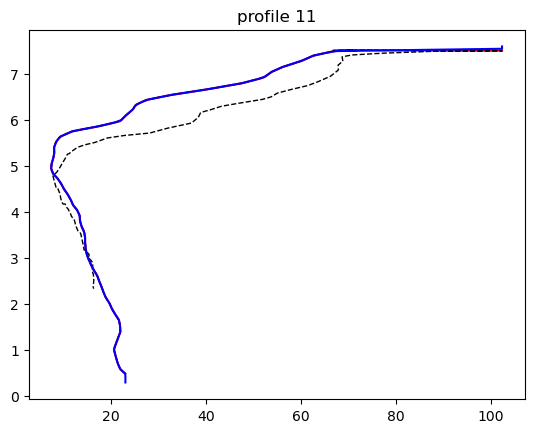

In [19]:
trash1 = np.interp(z_norm, data['dados_ctd'][20][1][1743:1814], data['dados_ctd'][20][3][1743:1814])
trash2 = np.interp(z_norm, data['dados_ctd'][20][1][1743:1814], data['dados_ctd'][20][5][1743:1814])
trash3 = np.interp(z_norm, data['dados_ctd'][20][1][1743:1814], data['dados_ctd'][20][4][1743:1814])
trash4 = np.interp(z_norm, data['dados_ctd'][20][1][1743:1814], data['dados_ctd'][20][6][1743:1814])
trash5 = np.interp(z_norm, data['dados_ctd'][20][1][1743:1814], data['dados_ctd'][20][2][1743:1814])
trash6 = np.interp(z_norm, data['dados_ctd'][20][1][1743:1814], data['dados_ctd'][20][7][1743:1814])
trash1[147:] = np.nan
trash2[147:] = np.nan
trash3[147:] = np.nan
trash4[147:] = np.nan
trash5[147:] = np.nan
trash6[147:] = np.nan

plt.title('profile 11')
plt.plot(data['dados_ctd'][20][5][1743:1814], data['dados_ctd'][20][1][1743:1814], 'r')
plt.plot(data['dados_ctd'][20][5][1743:1900], data['dados_ctd'][20][1][1743:1900], 'k', ls='--', lw=1)
plt.plot(trash2, z_norm, 'b')



sal_norm[10] = trash1
turb_norm[10] = trash2
cla_norm[10] = trash3
od_norm[10] = trash4
temp_norm[10] = trash5
dens_norm[10] = trash6

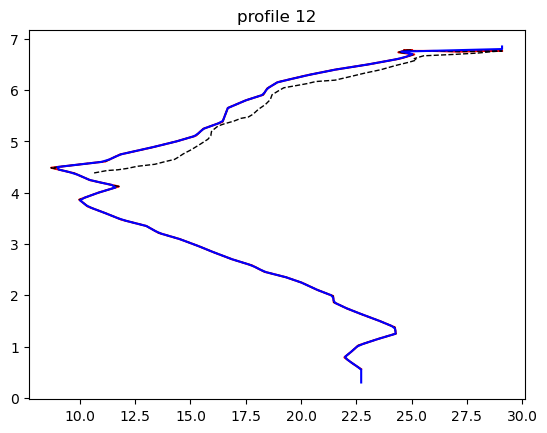

In [20]:
trash1 = np.interp(z_norm, data['dados_ctd'][20][1][1947:2007], data['dados_ctd'][20][3][1947:2007])
trash2 = np.interp(z_norm, data['dados_ctd'][20][1][1947:2007], data['dados_ctd'][20][5][1947:2007])
trash3 = np.interp(z_norm, data['dados_ctd'][20][1][1947:2007], data['dados_ctd'][20][4][1947:2007])
trash4 = np.interp(z_norm, data['dados_ctd'][20][1][1947:2007], data['dados_ctd'][20][6][1947:2007])
trash5 = np.interp(z_norm, data['dados_ctd'][20][1][1947:2007], data['dados_ctd'][20][2][1947:2007])
trash6 = np.interp(z_norm, data['dados_ctd'][20][1][1947:2007], data['dados_ctd'][20][7][1947:2007])
trash1[132:] = np.nan
trash2[132:] = np.nan
trash3[132:] = np.nan
trash4[132:] = np.nan
trash5[132:] = np.nan
trash6[132:] = np.nan

plt.title('profile 12')
plt.plot(data['dados_ctd'][20][5][1947:2007], data['dados_ctd'][20][1][1947:2007], 'r')
plt.plot(data['dados_ctd'][20][5][1947:2050], data['dados_ctd'][20][1][1947:2050], 'k', ls='--', lw=1)
plt.plot(trash2, z_norm, 'b')



sal_norm[11] = trash1
turb_norm[11] = trash2
cla_norm[11] = trash3
od_norm[11] = trash4
temp_norm[11] = trash5
dens_norm[11] = trash6

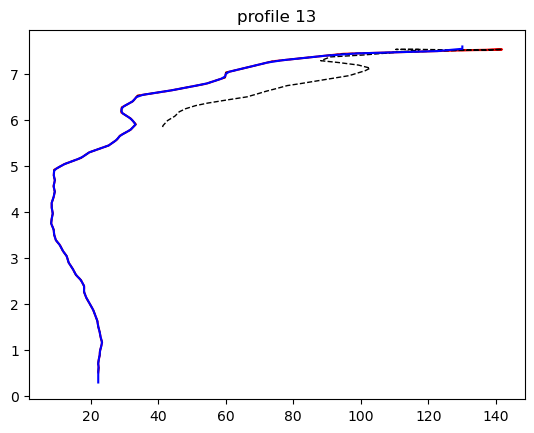

In [21]:
trash1 = np.interp(z_norm, data['dados_ctd'][20][1][2157:2220], data['dados_ctd'][20][3][2157:2220])
trash2 = np.interp(z_norm, data['dados_ctd'][20][1][2157:2220], data['dados_ctd'][20][5][2157:2220])
trash3 = np.interp(z_norm, data['dados_ctd'][20][1][2157:2220], data['dados_ctd'][20][4][2157:2220])
trash4 = np.interp(z_norm, data['dados_ctd'][20][1][2157:2220], data['dados_ctd'][20][6][2157:2220])
trash5 = np.interp(z_norm, data['dados_ctd'][20][1][2157:2220], data['dados_ctd'][20][2][2157:2220])
trash6 = np.interp(z_norm, data['dados_ctd'][20][1][2157:2220], data['dados_ctd'][20][7][2157:2220])
trash1[147:] = np.nan
trash2[147:] = np.nan
trash3[147:] = np.nan
trash4[147:] = np.nan
trash5[147:] = np.nan
trash6[147:] = np.nan

plt.title('profile 13')
plt.plot(data['dados_ctd'][20][5][2157:2220], data['dados_ctd'][20][1][2157:2220], 'r')
plt.plot(data['dados_ctd'][20][5][2157:2250], data['dados_ctd'][20][1][2157:2250], 'k', ls='--', lw=1)
plt.plot(trash2, z_norm, 'b')



sal_norm[12] = trash1
turb_norm[12] = trash2
cla_norm[12] = trash3
od_norm[12] = trash4
temp_norm[12] = trash5
dens_norm[12] = trash6

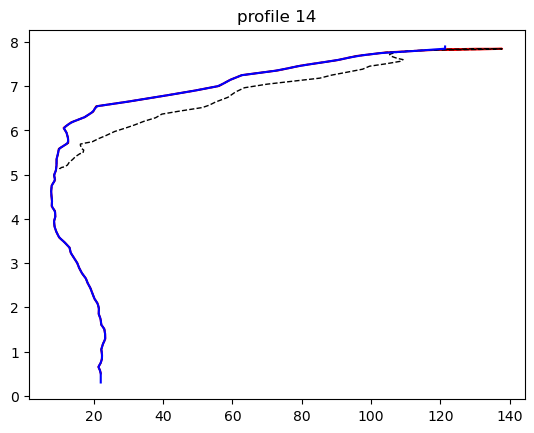

In [22]:
trash1 = np.interp(z_norm, data['dados_ctd'][20][1][2383:2453], data['dados_ctd'][20][3][2383:2453])
trash2 = np.interp(z_norm, data['dados_ctd'][20][1][2383:2453], data['dados_ctd'][20][5][2383:2453])
trash3 = np.interp(z_norm, data['dados_ctd'][20][1][2383:2453], data['dados_ctd'][20][4][2383:2453])
trash4 = np.interp(z_norm, data['dados_ctd'][20][1][2383:2453], data['dados_ctd'][20][6][2383:2453])
trash5 = np.interp(z_norm, data['dados_ctd'][20][1][2383:2453], data['dados_ctd'][20][2][2383:2453])
trash6 = np.interp(z_norm, data['dados_ctd'][20][1][2383:2453], data['dados_ctd'][20][7][2383:2453])
trash1[153:] = np.nan
trash2[153:] = np.nan
trash3[153:] = np.nan
trash4[153:] = np.nan
trash5[153:] = np.nan
trash6[153:] = np.nan

plt.title('profile 14')
plt.plot(data['dados_ctd'][20][5][2383:2453], data['dados_ctd'][20][1][2383:2453], 'r')
plt.plot(data['dados_ctd'][20][5][2383:2500], data['dados_ctd'][20][1][2383:2500], 'k', ls='--', lw=1)
plt.plot(trash2, z_norm, 'b')


sal_norm[13] = trash1
turb_norm[13] = trash2
cla_norm[13] = trash3
od_norm[13] = trash4
temp_norm[13] = trash5
dens_norm[13] = trash6

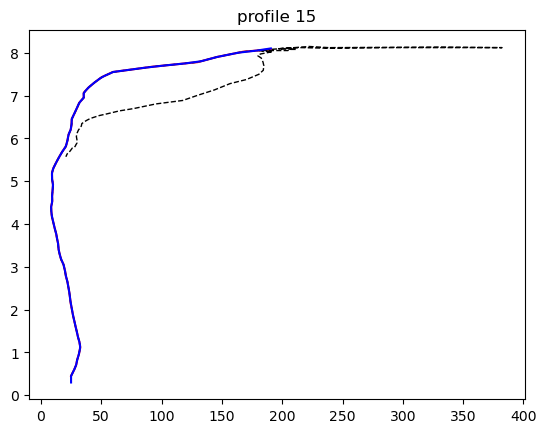

In [23]:
trash1 = np.interp(z_norm, data['dados_ctd'][20][1][2634:2696], data['dados_ctd'][20][3][2634:2696])
trash2 = np.interp(z_norm, data['dados_ctd'][20][1][2634:2696], data['dados_ctd'][20][5][2634:2696])
trash3 = np.interp(z_norm, data['dados_ctd'][20][1][2634:2696], data['dados_ctd'][20][4][2634:2696])
trash4 = np.interp(z_norm, data['dados_ctd'][20][1][2634:2696], data['dados_ctd'][20][6][2634:2696])
trash5 = np.interp(z_norm, data['dados_ctd'][20][1][2634:2696], data['dados_ctd'][20][2][2634:2696])
trash6 = np.interp(z_norm, data['dados_ctd'][20][1][2634:2696], data['dados_ctd'][20][7][2634:2696])
trash1[157:] = np.nan
trash2[157:] = np.nan
trash3[157:] = np.nan
trash4[157:] = np.nan
trash5[157:] = np.nan
trash6[157:] = np.nan

plt.title('profile 15')
plt.plot(data['dados_ctd'][20][5][2634:2696], data['dados_ctd'][20][1][2634:2696], 'r')
plt.plot(data['dados_ctd'][20][5][2634:2750], data['dados_ctd'][20][1][2634:2750], 'k', ls='--', lw=1)
plt.plot(trash2, z_norm, 'b')



sal_norm[14] = trash1
turb_norm[14] = trash2
cla_norm[14] = trash3
od_norm[14] = trash4
temp_norm[14] = trash5
dens_norm[14] = trash6

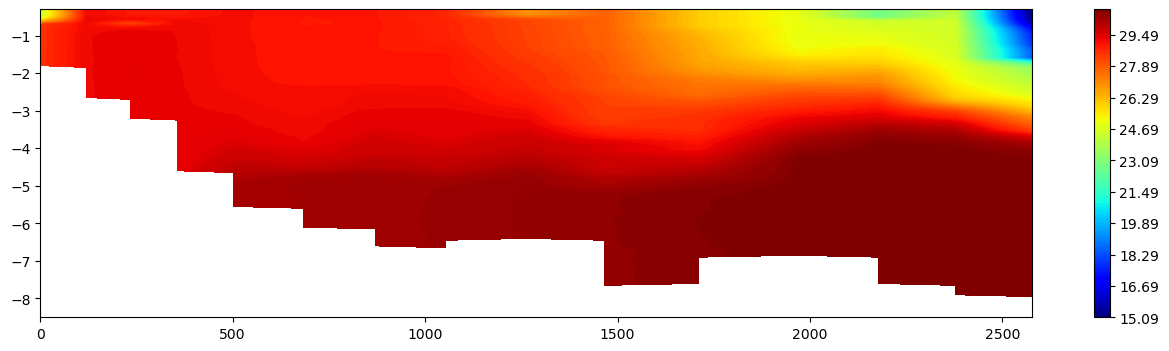

In [24]:
fig, ax = plt.subplots(figsize=(16,4), dpi = 100)


q = ax.contourf(ctd_cumdist, -z_norm, sal_norm.T, np.arange(np.nanmin(sal_norm),np.nanmax(sal_norm)+0.1,0.1), cmap=plt.cm.jet)
plt.colorbar(q)

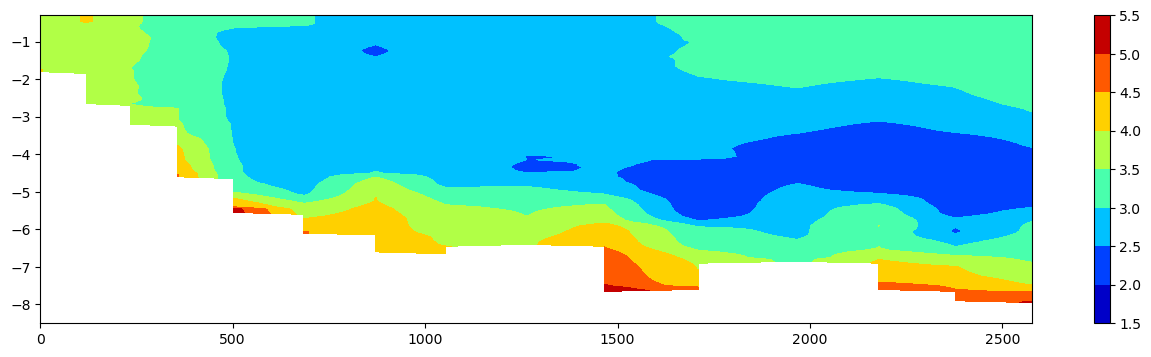

In [25]:
fig, ax = plt.subplots(figsize=(16,4), dpi = 100)

q = ax.contourf(ctd_cumdist, -z_norm, np.log(turb_norm.T),  cmap=plt.cm.jet)
plt.colorbar(q)

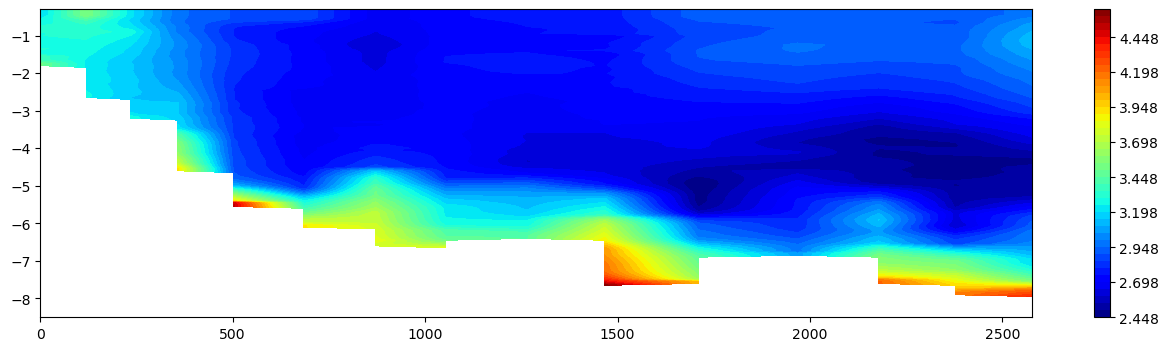

In [26]:
ssc = 8.215 + 0.455*turb_norm#-1.05+1.03*turb_norm

fig, ax = plt.subplots(figsize=(16,4), dpi = 100)

q = ax.contourf(ctd_cumdist, -z_norm, np.log(ssc.T), np.arange(np.nanmin(np.log(ssc.T)),np.nanmax(np.log(ssc.T))+0.05,0.05),  cmap=plt.cm.jet)
plt.colorbar(q)

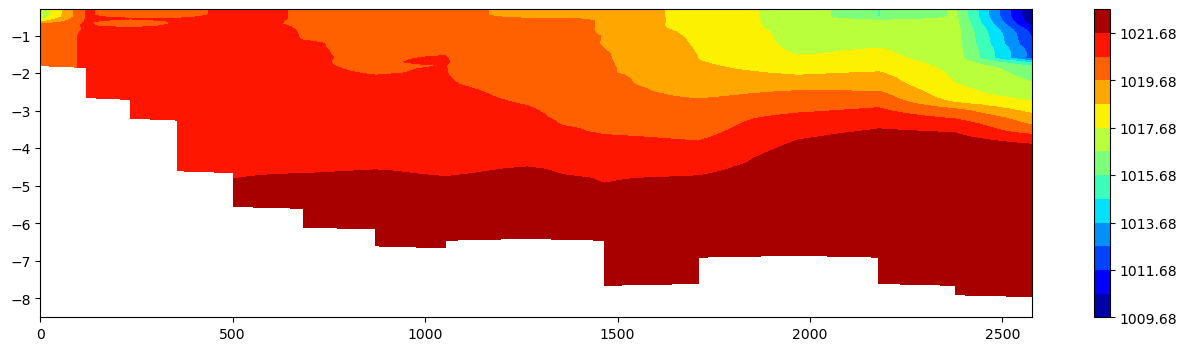

In [27]:
fig, ax = plt.subplots(figsize=(16,4), dpi = 100)

q = ax.contourf(ctd_cumdist, -z_norm, (dens_norm.T), (np.arange(np.nanmin(dens_norm),np.nanmax(dens_norm)+1,1)),  cmap=plt.cm.jet)
plt.colorbar(q)

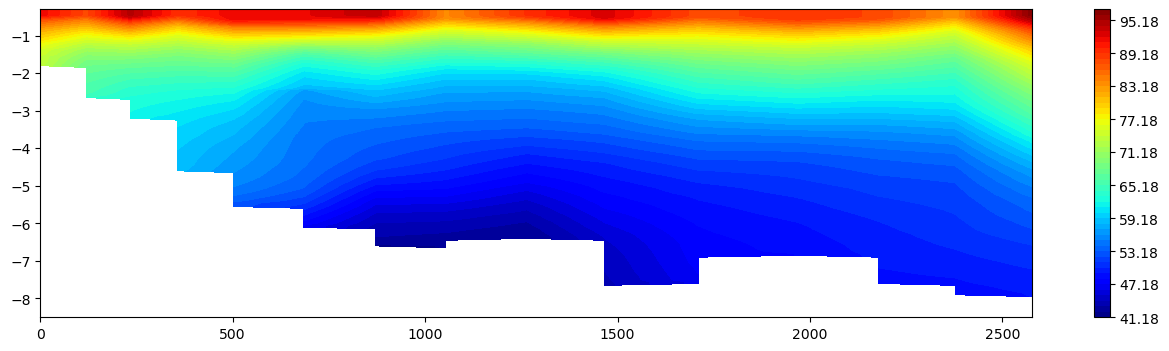

In [28]:
fig, ax = plt.subplots(figsize=(16,4), dpi = 100)

q = ax.contourf(ctd_cumdist, -z_norm, (od_norm.T), (np.arange(np.nanmin(od_norm),np.nanmax(od_norm)+1,1)),  cmap=plt.cm.jet)
plt.colorbar(q)

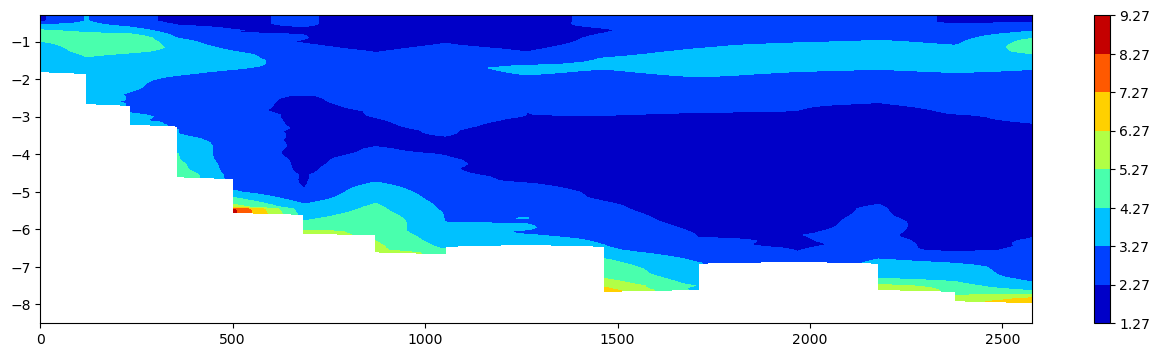

In [29]:
fig, ax = plt.subplots(figsize=(16,4), dpi = 100)

q = ax.contourf(ctd_cumdist, -z_norm, (cla_norm.T), (np.arange(np.nanmin(cla_norm),np.nanmax(cla_norm)+1,1)),  cmap=plt.cm.jet)
plt.colorbar(q)

In [30]:
dados_ctd4 = np.zeros((10,165,15))
dados_ctd4[0] = sal_norm.T
dados_ctd4[1] = turb_norm.T
dados_ctd4[2] = ssc.T
dados_ctd4[3] = cla_norm.T
dados_ctd4[4] = od_norm.T
dados_ctd4[5] = temp_norm.T
dados_ctd4[6] = dens_norm.T
dados_ctd4[7] = ctd_cumdist
dados_ctd4[8] = ctd_loc[:,0]
dados_ctd4[9] = ctd_loc[:,1]


with open('C:\\Users\\simcosta\\Documents\\doc\\Campo_2023\\Campo_2023\\Processados\\CTD4_REV.pkl', 'wb') as file:
    pickle.dump(dados_ctd4, file)

In [31]:
1

1